# Erasmus+ Mobility Network Analysis — Refined Version

Run the setup cell first, then the plot functions cell, then each plot cell separately. The first two cells define all reusable data tables and plotting functions.

In [ ]:
from dataclasses import dataclass
import json
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import ticker
from networkx.readwrite import json_graph


@dataclass(frozen=True)
class AnalysisConfig:
    years: tuple = tuple(range(2014, 2023))
    periods: tuple = ("2014-2016", "2017-2019", "2020-2022")
    uk_name: str = "UK - United Kingdom"


CONFIG = AnalysisConfig()

PERIOD_YEARS = {
    "2014-2016": range(2014, 2017),
    "2017-2019": range(2017, 2020),
    "2020-2022": range(2020, 2023),
}


YEARS = CONFIG.years
PERIODS = CONFIG.periods
UK_NAME = CONFIG.uk_name
def find_project_dir() -> Path:
    """Return the project root whether the notebook/script is run from project/ or project/scripts/."""
    cwd = Path.cwd().resolve()

    if cwd.name == "scripts":
        return cwd.parent

    if (cwd / "data").exists() or (cwd / "scripts").exists():
        return cwd

    if (cwd.parent / "data").exists() or (cwd.parent / "scripts").exists():
        return cwd.parent

    # Fallback: keep outputs near the current working directory.
    return cwd


PROJECT_DIR = find_project_dir()
DATA_DIR = PROJECT_DIR / "data"
GRAPH_DIR = DATA_DIR / "ka2_graphs"
PLOTS_DIR = DATA_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Plots will be saved to: {PLOTS_DIR}")


def save_plot(fig, filename: str, dpi: int = 300) -> Path:
    """Save a matplotlib figure to data/plots and return the saved path."""
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)

    if not filename.lower().endswith(".png"):
        filename = f"{filename}.png"

    output_path = PLOTS_DIR / filename
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    return output_path


mpl.rcParams.update({
    "figure.figsize": (6, 5),
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 1,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "xtick.minor.size": 1.25,
    "ytick.minor.size": 1.25,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.5,
    "ytick.minor.width": 0.5,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def assign_period(year: int) -> str:
    """Return the analysis period label for a given year."""
    if year <= 2016:
        return "2014-2016"
    if year <= 2019:
        return "2017-2019"
    return "2020-2022"


def short_country_name(country: str) -> str:
    """Return the country code from labels like 'FI - Finland'."""
    return str(country).split(" - ")[0]


def parse_language_codes(value) -> set:
    """Turn a language-family string such as '1,3,4' into a set of codes."""
    if pd.isna(value):
        return set()
    return set(str(value).replace(" ", "").split(","))


def has_shared_language(row: pd.Series) -> bool:
    """Check whether the source and target countries share any language-family code."""
    source_codes = parse_language_codes(row["source_language"])
    target_codes = parse_language_codes(row["target_language"])
    return bool(source_codes.intersection(target_codes))


def safe_share(numerator: float, denominator: float) -> float:
    """Return numerator / denominator, avoiding division by zero."""
    return np.nan if denominator == 0 else numerator / denominator


def graph_path(year: int, graph_dir: Path = GRAPH_DIR) -> Path:
    """Return the expected file path for a yearly graph.

    The notebook normally expects files in ka2_graphs/. The fallback makes the
    notebook easier to test if the JSON files are in the current directory.
    """
    path = graph_dir / f"ka2_mobility_network_{year}.json"
    if path.exists():
        return path

    fallback = Path(f"ka2_mobility_network_{year}.json")
    if fallback.exists():
        return fallback

    raise FileNotFoundError(f"Could not find graph JSON for {year}: {path}")


def load_graph(year: int, graph_dir: Path = GRAPH_DIR) -> nx.DiGraph:
    """Load one yearly directed weighted graph from JSON."""
    with graph_path(year, graph_dir).open("r", encoding="utf-8") as f:
        data = json.load(f)

    return json_graph.node_link_graph(data, directed=True, edges="edges")


def combine_period_graph(years, graph_dir: Path = GRAPH_DIR) -> nx.DiGraph:
    """Combine yearly graphs into one directed weighted graph for a period."""
    combined = nx.DiGraph()

    for year in years:
        yearly_graph = load_graph(year, graph_dir)

        for node, attrs in yearly_graph.nodes(data=True):
            if node not in combined:
                combined.add_node(node, **attrs)

        for source, target, attrs in yearly_graph.edges(data=True):
            weight = attrs.get("weight", 1)

            if combined.has_edge(source, target):
                combined[source][target]["weight"] += weight
            else:
                combined.add_edge(source, target, weight=weight)

    return combined


def build_edges_df(years=YEARS) -> pd.DataFrame:
    """Create one row per directed country-country edge per year."""
    rows = []

    for year in years:
        graph = load_graph(year)

        for source, target, attrs in graph.edges(data=True):
            source_attrs = graph.nodes[source]
            target_attrs = graph.nodes[target]

            rows.append({
                "year": year,
                "period": assign_period(year),
                "source": source,
                "target": target,
                "weight": attrs.get("weight", 1),
                "source_region": source_attrs.get("geographical_cultural_region"),
                "target_region": target_attrs.get("geographical_cultural_region"),
                "source_economy": source_attrs.get("economic_family"),
                "target_economy": target_attrs.get("economic_family"),
                "source_language": source_attrs.get("language_family"),
                "target_language": target_attrs.get("language_family"),
                "source_lat": source_attrs.get("lat"),
                "source_lon": source_attrs.get("lon"),
                "target_lat": target_attrs.get("lat"),
                "target_lon": target_attrs.get("lon"),
            })

    edges = pd.DataFrame(rows)

    # Homophily / similarity columns used by several plots.
    edges["same_region"] = edges["source_region"].eq(edges["target_region"])
    edges["same_economy"] = edges["source_economy"].eq(edges["target_economy"])
    edges["same_language"] = edges.apply(has_shared_language, axis=1)

    return edges


def build_summary_df(years=YEARS) -> pd.DataFrame:
    """Create one row per year with whole-network metrics."""
    rows = []

    for year in years:
        graph = load_graph(year)
        total_weight = sum(attrs.get("weight", 1) for _, _, attrs in graph.edges(data=True))

        rows.append({
            "year": year,
            "total_weight": total_weight,
            "num_edges": graph.number_of_edges(),
            "num_nodes": graph.number_of_nodes(),
            "density": nx.density(graph),
            "reciprocity": nx.reciprocity(graph),
        })

    return pd.DataFrame(rows)


def country_metrics_from_edges(edges: pd.DataFrame, group_col: str) -> pd.DataFrame:
    """Calculate incoming, outgoing, total, and net mobility by country and group."""
    rows = []

    for group_value, group in edges.groupby(group_col):
        incoming = group.groupby("target")["weight"].sum().rename("in_strength")
        outgoing = group.groupby("source")["weight"].sum().rename("out_strength")

        stats = pd.concat([incoming, outgoing], axis=1).fillna(0)
        stats["total_strength"] = stats["in_strength"] + stats["out_strength"]
        stats["net_flow"] = stats["in_strength"] - stats["out_strength"]
        stats = stats.reset_index().rename(columns={"index": "country"})
        stats["country_code"] = stats["country"].map(short_country_name)
        stats[group_col] = group_value

        rows.append(stats)

    return pd.concat(rows, ignore_index=True)


def build_country_df(edges: pd.DataFrame = None) -> pd.DataFrame:
    """Create yearly country-level incoming/outgoing mobility metrics."""
    if edges is None:
        edges = edges_df
    return country_metrics_from_edges(edges, group_col="year")


def build_country_avg(country_df: pd.DataFrame) -> pd.DataFrame:
    """Average country-level mobility metrics across all years."""
    return (
        country_df
        .groupby(["country", "country_code"], as_index=False)
        [["in_strength", "out_strength", "total_strength", "net_flow"]]
        .mean()
    )


def build_centrality_df(period_years=PERIOD_YEARS) -> pd.DataFrame:
    """Calculate period-level hub and bridge metrics."""
    rows = []

    for period, years in period_years.items():
        graph = combine_period_graph(years)

        in_strength = dict(graph.in_degree(weight="weight"))
        out_strength = dict(graph.out_degree(weight="weight"))
        total_strength = {
            node: in_strength.get(node, 0) + out_strength.get(node, 0)
            for node in graph.nodes()
        }

        pagerank = nx.pagerank(graph, weight="weight")

        # For betweenness, edge weights need to behave like distances.
        # Strong mobility links are treated as short distances.
        distance_graph = graph.copy()
        nx.set_edge_attributes(
            distance_graph,
            {(u, v): 1 / attrs.get("weight", 1) for u, v, attrs in distance_graph.edges(data=True)},
            "distance",
        )
        betweenness = nx.betweenness_centrality(distance_graph, weight="distance", normalized=True)

        for country in graph.nodes():
            rows.append({
                "period": period,
                "country": country,
                "country_code": short_country_name(country),
                "in_strength": in_strength.get(country, 0),
                "out_strength": out_strength.get(country, 0),
                "total_strength": total_strength.get(country, 0),
                "net_flow": in_strength.get(country, 0) - out_strength.get(country, 0),
                "pagerank": pagerank.get(country, 0),
                "betweenness": betweenness.get(country, 0),
            })

    return pd.DataFrame(rows)


edges_df = build_edges_df()
summary_df = build_summary_df()
country_df = build_country_df(edges_df)
country_avg = build_country_avg(country_df)
centrality_df = build_centrality_df()


print("Setup complete.")
print(f"edges_df:      {edges_df.shape}")
print(f"summary_df:    {summary_df.shape}")
print(f"country_df:    {country_df.shape}")
print(f"country_avg:   {country_avg.shape}")
print(f"centrality_df: {centrality_df.shape}")

Plots will be saved to: C:\Users\Nikolasz\Downloads\CSS-project\CompSocialScience_Erasmus\data\plots
Setup complete.
edges_df:      (7078, 18)
summary_df:    (9, 6)
country_df:    (302, 7)
country_avg:   (39, 6)
centrality_df: (117, 9)


In [3]:
def finish_plot(title=None, xlabel=None, ylabel=None, legend=False, grid_axis="both"):
    """Small helper to keep plot formatting consistent."""
    if title:
        plt.title(title)
    if xlabel:
        plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    if legend:
        plt.legend()
    if grid_axis:
        plt.grid(axis=grid_axis, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_total_mobility(summary_df: pd.DataFrame):
    """Plot total yearly Erasmus+ mobility volume."""
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(summary_df["year"], summary_df["total_weight"], marker="o", linewidth=2)
    ax.axvline(2016, linestyle="--", label="Brexit referendum", color="orange")
    ax.axvline(2020, linestyle="--", label="Start of COVID-19", color="red")
    ax.axvline(2022, linestyle="--", label="Near end of COVID period", color="green")

    ax.set_xlabel("Year")
    ax.set_ylabel("Total edge weight")
    ax.set_title("Total Erasmus+ Mobility Volume Over Time")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    save_plot(fig, "total_mobility.png")
    plt.show()

def plot_similarity_shares(edges_df: pd.DataFrame) -> pd.DataFrame:
    """Plot the yearly share of mobility occurring between similar countries."""
    similarity_df = (
        edges_df
        .groupby("year")
        .apply(lambda g: pd.Series({
            "same_region_share": safe_share(g.loc[g["same_region"], "weight"].sum(), g["weight"].sum()),
            "same_language_share": safe_share(g.loc[g["same_language"], "weight"].sum(), g["weight"].sum()),
            "same_economy_share": safe_share(g.loc[g["same_economy"], "weight"].sum(), g["weight"].sum()),
        }))
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(similarity_df["year"], similarity_df["same_region_share"], marker="o", label="Same region")
    ax.plot(similarity_df["year"], similarity_df["same_language_share"], marker="o", label="Same language family")
    ax.plot(similarity_df["year"], similarity_df["same_economy_share"], marker="o", label="Same economic group")

    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
    ax.set_xlabel("Year")
    ax.set_ylabel("Share of total mobility weight")
    ax.set_title("Similarity-Based Mobility Shares Over Time")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    save_plot(fig, "similarity_shares.png")
    plt.show()
    
    return similarity_df


def plot_concentration_curve(edges_df: pd.DataFrame, periods=PERIODS):
    """Plot cumulative mobility concentration across the strongest country-country edges."""
    fig, ax = plt.subplots(figsize=(8, 6))

    for period in periods:
        period_df = edges_df.loc[edges_df["period"] == period].sort_values("weight", ascending=False).copy()
        period_df["edge_share"] = np.arange(1, len(period_df) + 1) / len(period_df)
        period_df["mobility_share"] = period_df["weight"].cumsum() / period_df["weight"].sum()

        ax.plot(
            period_df["edge_share"] * 100,
            period_df["mobility_share"] * 100,
            linewidth=2,
            label=period,
        )

    ax.plot([0, 100], [0, 100], linestyle="--", label="Perfectly even distribution")
    ax.set_xlabel("Top X% of country-country edges")
    ax.set_ylabel("Cumulative share of total mobility weight (%)")
    ax.set_title("Mobility Concentration Across Country-Country Corridors")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    save_plot(fig, "concentration_curve.png")
    plt.show()
    


def plot_region_heatmaps_share(edges_df: pd.DataFrame, periods=PERIODS) -> dict:
    """Plot normalized region-to-region heatmaps. Each period sums to 100%."""
    region_flow = (
        edges_df
        .groupby(["period", "source_region", "target_region"], as_index=False)["weight"]
        .sum()
    )

    regions = sorted(set(edges_df["source_region"].dropna()).union(edges_df["target_region"].dropna()))
    matrices = {}

    for period in periods:
        matrix = (
            region_flow.loc[region_flow["period"] == period]
            .pivot(index="source_region", columns="target_region", values="weight")
            .reindex(index=regions, columns=regions)
            .fillna(0)
        )
        matrices[period] = matrix / matrix.values.sum() * 100

    vmax = max(matrix.values.max() for matrix in matrices.values())

    fig, axes = plt.subplots(1, len(periods), figsize=(18, 5), sharey=True)

    for ax, period in zip(axes, periods):
        matrix = matrices[period]
        image = ax.imshow(matrix, cmap="YlGn", vmin=0, vmax=vmax)

        ax.set_title(period)
        ax.set_xticks(range(len(regions)))
        ax.set_xticklabels(regions, rotation=45, ha="right")
        ax.set_yticks(range(len(regions)))
        ax.set_yticklabels(regions)
        ax.set_xlabel("Receiver region")

        for i in range(len(regions)):
            for j in range(len(regions)):
                ax.text(j, i, f"{matrix.iloc[i, j]:.1f}%", ha="center", va="center", fontsize=8)

    axes[0].set_ylabel("Sender region")
    fig.suptitle("Share of Erasmus+ Mobility Between Regions by Period", fontsize=14)
    colorbar = fig.colorbar(image, ax=axes, fraction=0.025, pad=0.04)
    colorbar.set_label("Share of total period mobility (%)")
    save_plot(fig, "region_heatmaps.png")
    plt.show()

    return matrices

def plot_region_flow_row_percentages(edges_df: pd.DataFrame, save: bool = False) -> None:
    """
    Plot region-to-region mobility shares by period.

    Each row sums to 100%.
    Interpretation:
    Of all mobility sent from source region X, what percentage goes to target region Y?
    """

    region_flow = (
        edges_df
        .groupby(["period", "source_region", "target_region"], as_index=False)["weight"]
        .sum()
    )

    regions = sorted(
        set(edges_df["source_region"].dropna()).union(
            set(edges_df["target_region"].dropna())
        )
    )

    matrices = {}

    for period in PERIODS:
        matrix = (
            region_flow[region_flow["period"] == period]
            .pivot(index="source_region", columns="target_region", values="weight")
            .reindex(index=regions, columns=regions)
            .fillna(0)
        )

        # Row-normalize: each sender region sums to 100%
        row_sums = matrix.sum(axis=1).replace(0, np.nan)
        matrix_percent = matrix.div(row_sums, axis=0) * 100

        matrices[period] = matrix_percent.fillna(0)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for ax, period in zip(axes, PERIODS):
        matrix = matrices[period]

        im = ax.imshow(
            matrix,
            cmap="YlGn",
            vmin=0,
            vmax=100
        )

        ax.set_title(period)
        ax.set_xticks(range(len(regions)))
        ax.set_xticklabels(regions, rotation=45, ha="right")
        ax.set_yticks(range(len(regions)))
        ax.set_yticklabels(regions)
        ax.set_xlabel("Receiver region")

        for i in range(len(regions)):
            for j in range(len(regions)):
                value = matrix.iloc[i, j]
                ax.text(
                    j,
                    i,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="black"
                )

    axes[0].set_ylabel("Sender region")

    fig.suptitle(
        "Destination Shares of Erasmus+ Mobility by Sender Region",
        fontsize=14
    )

    cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.04)
    cbar.set_label("Share of sender region mobility (%)")


    if save:
        save_plot(fig, "region_flow_row_percentages")

    plt.show()
    
def plot_region_flow_column_percentages(edges_df: pd.DataFrame, save: bool = False) -> None:
    """
    Plot region-to-region mobility shares by period.

    Each column sums to 100%.
    Interpretation:
    Of all mobility received by target region Y, what percentage comes from source region X?
    """

    region_flow = (
        edges_df
        .groupby(["period", "source_region", "target_region"], as_index=False)["weight"]
        .sum()
    )

    regions = sorted(
        set(edges_df["source_region"].dropna()).union(
            set(edges_df["target_region"].dropna())
        )
    )

    matrices = {}

    for period in PERIODS:
        matrix = (
            region_flow[region_flow["period"] == period]
            .pivot(index="source_region", columns="target_region", values="weight")
            .reindex(index=regions, columns=regions)
            .fillna(0)
        )

        # Column-normalize: each receiver region sums to 100%
        column_sums = matrix.sum(axis=0).replace(0, np.nan)
        matrix_percent = matrix.div(column_sums, axis=1) * 100

        matrices[period] = matrix_percent.fillna(0)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for ax, period in zip(axes, PERIODS):
        matrix = matrices[period]

        im = ax.imshow(
            matrix,
            cmap="YlGn",
            vmin=0,
            vmax=100
        )

        ax.set_title(period)
        ax.set_xticks(range(len(regions)))
        ax.set_xticklabels(regions, rotation=45, ha="right")
        ax.set_yticks(range(len(regions)))
        ax.set_yticklabels(regions)
        ax.set_xlabel("Receiver region")

        for i in range(len(regions)):
            for j in range(len(regions)):
                value = matrix.iloc[i, j]
                ax.text(
                    j,
                    i,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="black"
                )

    axes[0].set_ylabel("Sender region")

    fig.suptitle(
        "Source Shares of Erasmus+ Mobility by Receiver Region",
        fontsize=14
    )

    cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.04)
    cbar.set_label("Share of receiver region mobility (%)")


    if save:
        save_plot(fig, "region_flow_column_percentages")

    plt.show()

def plot_country_roles_diverging(country_avg: pd.DataFrame, top_n=39) -> pd.DataFrame:
    """Plot incoming, outgoing, and net sender/receiver role for the most active countries."""
    plot_df = (
        country_avg
        .nlargest(top_n, "total_strength")
        .sort_values("total_strength")
        .copy()
    )

    plot_df["sender_overlay"] = (-plot_df["net_flow"]).clip(lower=0)
    plot_df["receiver_overlay"] = (-plot_df["net_flow"]).clip(upper=0)

    fig, ax = plt.subplots(figsize=(11, 10))

    ax.barh(plot_df["country_code"], plot_df["out_strength"], label="Outgoing mobility", color="lightsalmon", edgecolor="black", linewidth=0.5)
    ax.barh(plot_df["country_code"], -plot_df["in_strength"], label="Incoming mobility", color="skyblue", edgecolor="black", linewidth=0.5)
    ax.barh(plot_df["country_code"], plot_df["sender_overlay"], label="Net sender imbalance (out > in)", color="red", alpha=0.8)
    ax.barh(plot_df["country_code"], plot_df["receiver_overlay"], label="Net receiver imbalance (in > out)", color="green", alpha=0.8)

    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("Average mobility volume")
    ax.set_ylabel("Country")
    ax.set_title("Incoming, Outgoing, and Net Erasmus+ Mobility by Country, 2014–2022")
    ax.legend(loc="lower right")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    plt.tight_layout()
    save_plot(fig, "country_outgoing_incoming.png")
    plt.show()

    return plot_df


def plot_uk_brexit(edges_df: pd.DataFrame, uk_name=UK_NAME) -> pd.DataFrame:
    """Plot the UK mobility trend over time."""
    uk_df = (
        edges_df
        .groupby("year")
        .apply(lambda g: pd.Series({
            "incoming": g.loc[g["target"] == uk_name, "weight"].sum(),
            "outgoing": g.loc[g["source"] == uk_name, "weight"].sum(),
        }))
        .reset_index()
    )
    uk_df["total"] = uk_df["incoming"] + uk_df["outgoing"]
    uk_df["net_flow"] = uk_df["incoming"] - uk_df["outgoing"]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(uk_df["year"], uk_df["incoming"], marker="o", linewidth=2, label="Incoming mobility")
    ax.plot(uk_df["year"], uk_df["outgoing"], marker="o", linewidth=2, label="Outgoing mobility")
    ax.plot(uk_df["year"], uk_df["total"], marker="o", linewidth=2, label="Total mobility")

    ymax = uk_df["total"].max()
    ax.axvline(2016, linestyle="--", color="gray", linewidth=1)
    ax.text(2016 + 0.05, ymax * 0.95, "Brexit referendum", rotation=90, va="top")
    ax.axvline(2020, linestyle="--", color="gray", linewidth=1)
    ax.text(2020 + 0.05, ymax * 0.95, "UK left EU / COVID", rotation=90, va="top")

    ax.set_xlabel("Year")
    ax.set_ylabel("Mobility weight")
    ax.set_title("UK Erasmus+ Mobility Before and After Brexit")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    save_plot(fig, "uk_brexit.png")
    plt.show()

    return uk_df


def plot_betweenness_by_period(centrality_df: pd.DataFrame, top_n=10, periods=PERIODS):
    """Plot the top bridge countries by betweenness centrality for each period."""
    fig, axes = plt.subplots(1, len(periods), figsize=(18, 5), sharex=True)

    for ax, period in zip(axes, periods):
        plot_df = (
            centrality_df.loc[centrality_df["period"] == period]
            .nlargest(top_n, "betweenness")
            .sort_values("betweenness")
        )

        ax.barh(plot_df["country_code"], plot_df["betweenness"], edgecolor="black")
        ax.set_title(period)
        ax.set_xlabel("Betweenness centrality")
        ax.grid(axis="x", linestyle="--", alpha=0.3)

    axes[0].set_ylabel("Country")
    fig.suptitle("Top Bridge Countries in Erasmus+ Network by Period", fontsize=14)
    plt.tight_layout()
    save_plot(fig, "betweenness_centrality.png")
    plt.show()


def plot_growth_contributors(centrality_df: pd.DataFrame, start_period="2014-2016", end_period="2020-2022", top_n=15) -> pd.DataFrame:
    """Plot countries with the largest mobility-strength growth between two periods."""
    growth_df = (
        centrality_df
        .pivot(index="country_code", columns="period", values="total_strength")
        .fillna(0)
    )
    growth_df["absolute_growth"] = growth_df[end_period] - growth_df[start_period]
    growth_df["relative_growth_percent"] = (
        growth_df["absolute_growth"] / growth_df[start_period].replace(0, pd.NA) * 100
    )
    growth_df = growth_df.reset_index()

    plot_df = growth_df.nlargest(top_n, "absolute_growth").sort_values("absolute_growth")

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(plot_df["country_code"], plot_df["absolute_growth"], edgecolor="black", color="mediumseagreen")
    ax.set_xlabel(f"Increase in total mobility strength, {end_period} − {start_period}")
    ax.set_ylabel("Country")
    ax.set_title("Countries Contributing Most to Erasmus+ Mobility Growth")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    plt.tight_layout()
    save_plot(fig, "growth_contributions.png")
    plt.show()

    return growth_df


def plot_activity_group_share(centrality_df: pd.DataFrame, periods=PERIODS) -> pd.DataFrame:
    """Plot activity share held by top/middle/bottom country groups."""
    rows = []

    for period in periods:
        period_df = (
            centrality_df.loc[centrality_df["period"] == period]
            .sort_values("total_strength", ascending=False)
            .reset_index(drop=True)
            .copy()
        )

        n = len(period_df)
        top_cutoff = int(n * 0.25)
        bottom_cutoff = int(n * 0.75)

        period_df["activity_group"] = "Middle 50%"
        period_df.loc[:top_cutoff - 1, "activity_group"] = "Top 25%"
        period_df.loc[bottom_cutoff:, "activity_group"] = "Bottom 25%"

        group_summary = (
            period_df
            .groupby("activity_group", as_index=False)["total_strength"]
            .sum()
        )
        group_summary["activity_share"] = group_summary["total_strength"] / period_df["total_strength"].sum() * 100
        group_summary["period"] = period
        rows.append(group_summary)

    activity_group_df = pd.concat(rows, ignore_index=True)
    activity_group_pivot = activity_group_df.pivot(index="period", columns="activity_group", values="activity_share")
    activity_group_pivot = activity_group_pivot[["Top 25%", "Middle 50%", "Bottom 25%"]]

    ax = activity_group_pivot.plot(kind="bar", stacked=True, figsize=(8, 5), edgecolor="black")
    fig = ax.get_figure()
    ax.set_ylabel("Share of total country mobility activity (%)")
    ax.set_xlabel("Period")
    ax.set_title("Mobility Activity Share by Country Activity Group")
    ax.set_xticklabels(activity_group_pivot.index, rotation=0)
    ax.legend(title="Country activity group", bbox_to_anchor=(1.05, 1), loc="upper left")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    save_plot(fig, "mobility_evolution_share.png")
    plt.show()

    return activity_group_df

## Overall network evolution

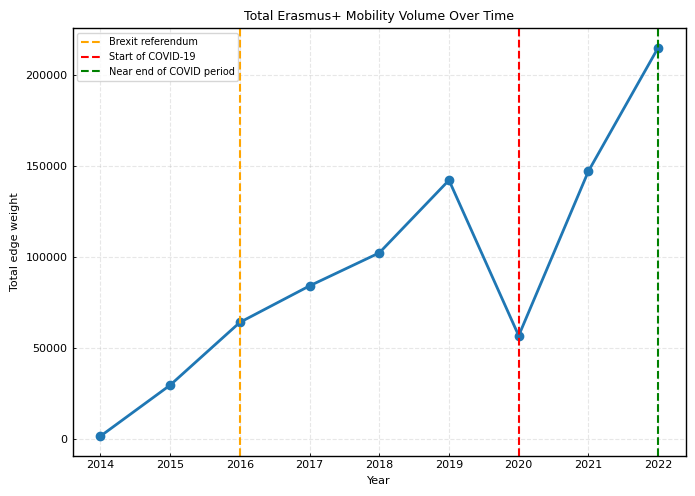

In [4]:
plot_total_mobility(summary_df)

## Similarity and homophily

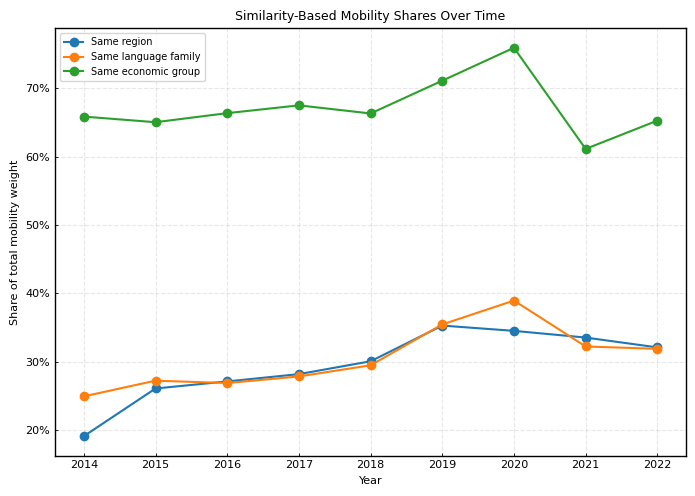

In [5]:
similarity_df = plot_similarity_shares(edges_df)

## Mobility concentration

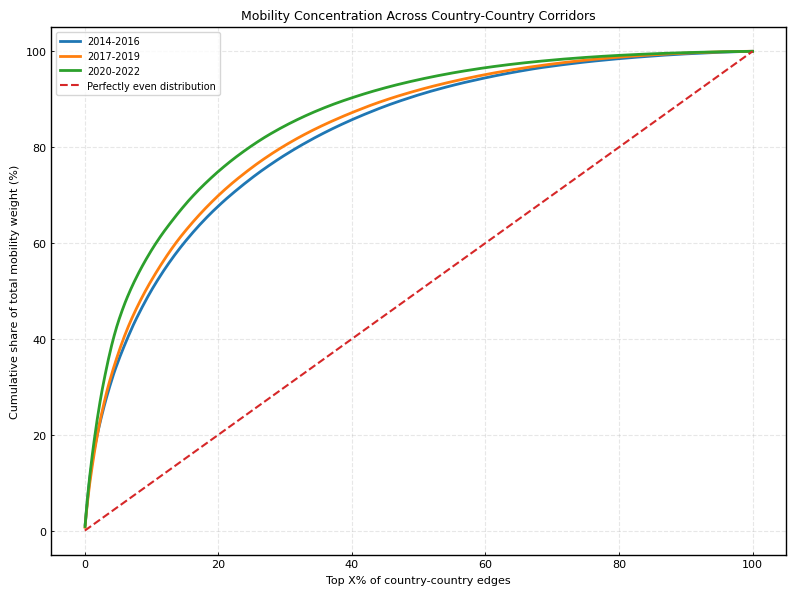

In [6]:
plot_concentration_curve(edges_df)

## Regional structure heatmaps

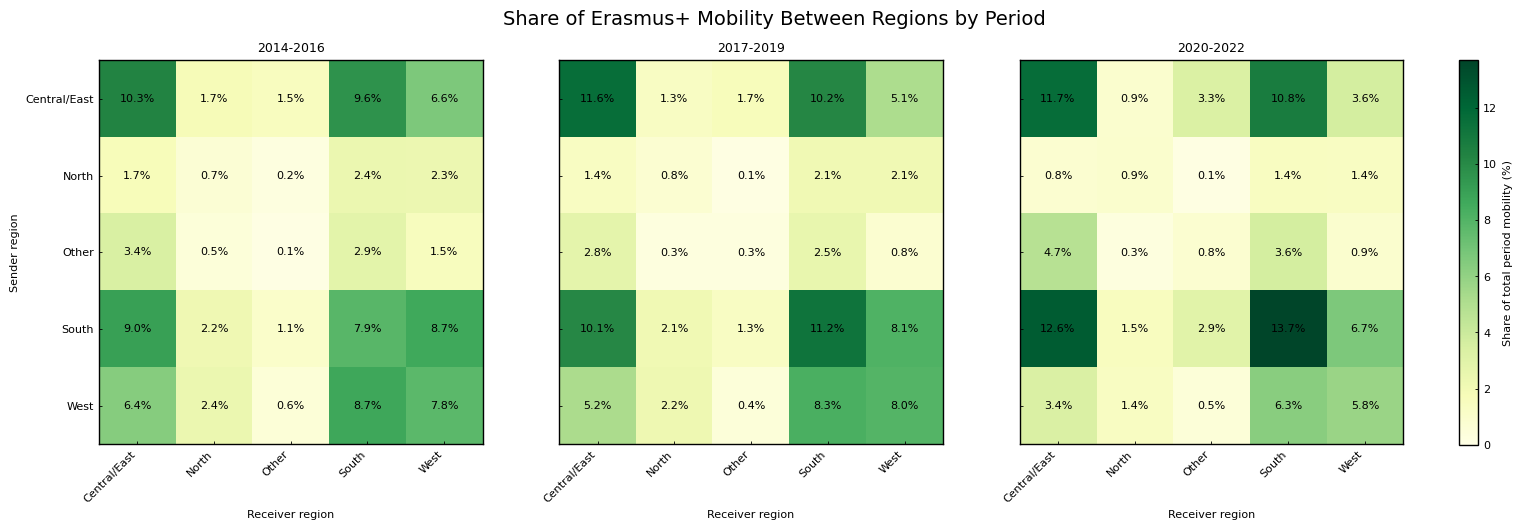

In [7]:
region_matrices = plot_region_heatmaps_share(edges_df)

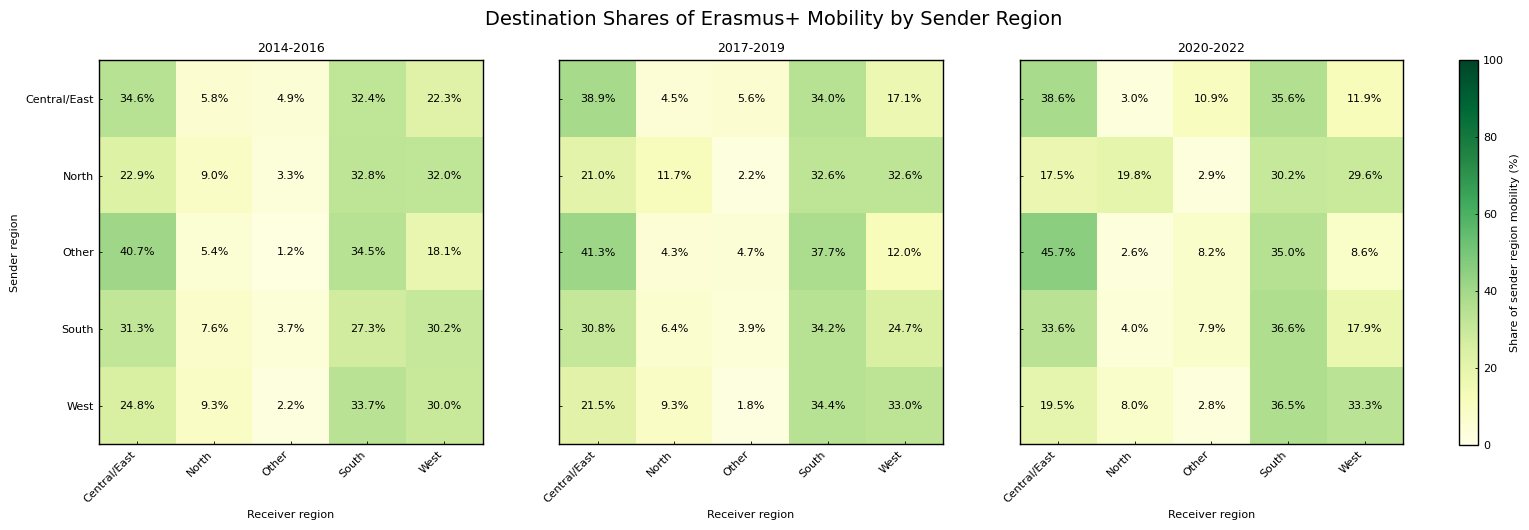

In [8]:
plot_region_flow_row_percentages(edges_df, save=True)

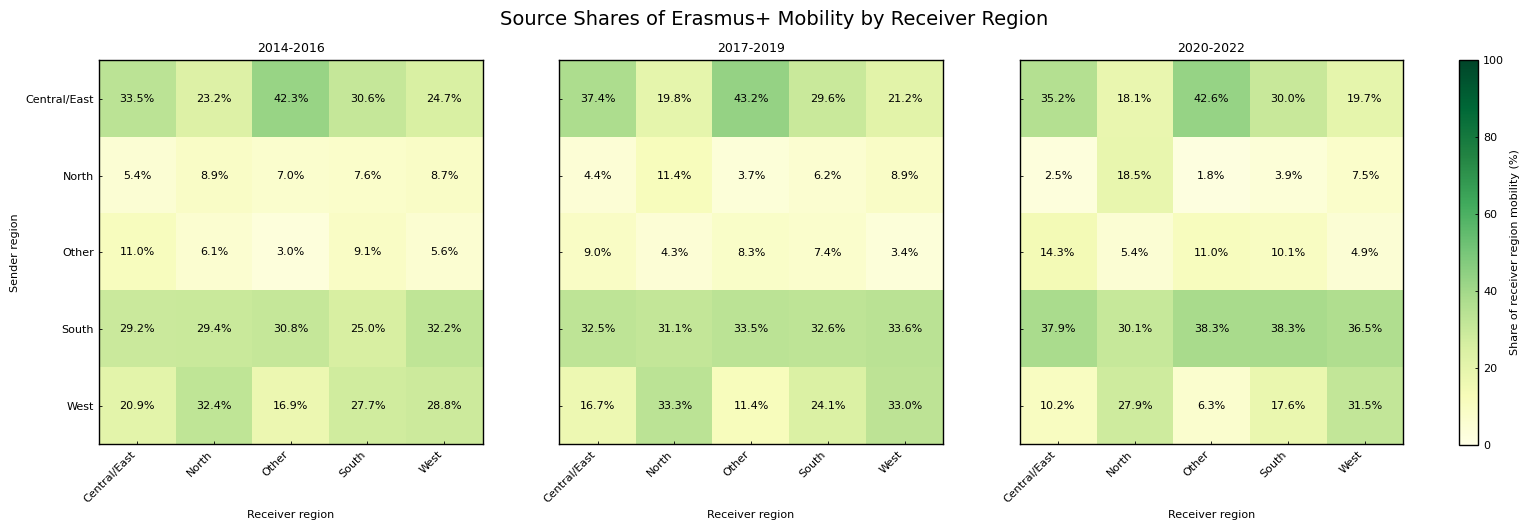

In [9]:
plot_region_flow_column_percentages(edges_df, save=True)

## Country roles

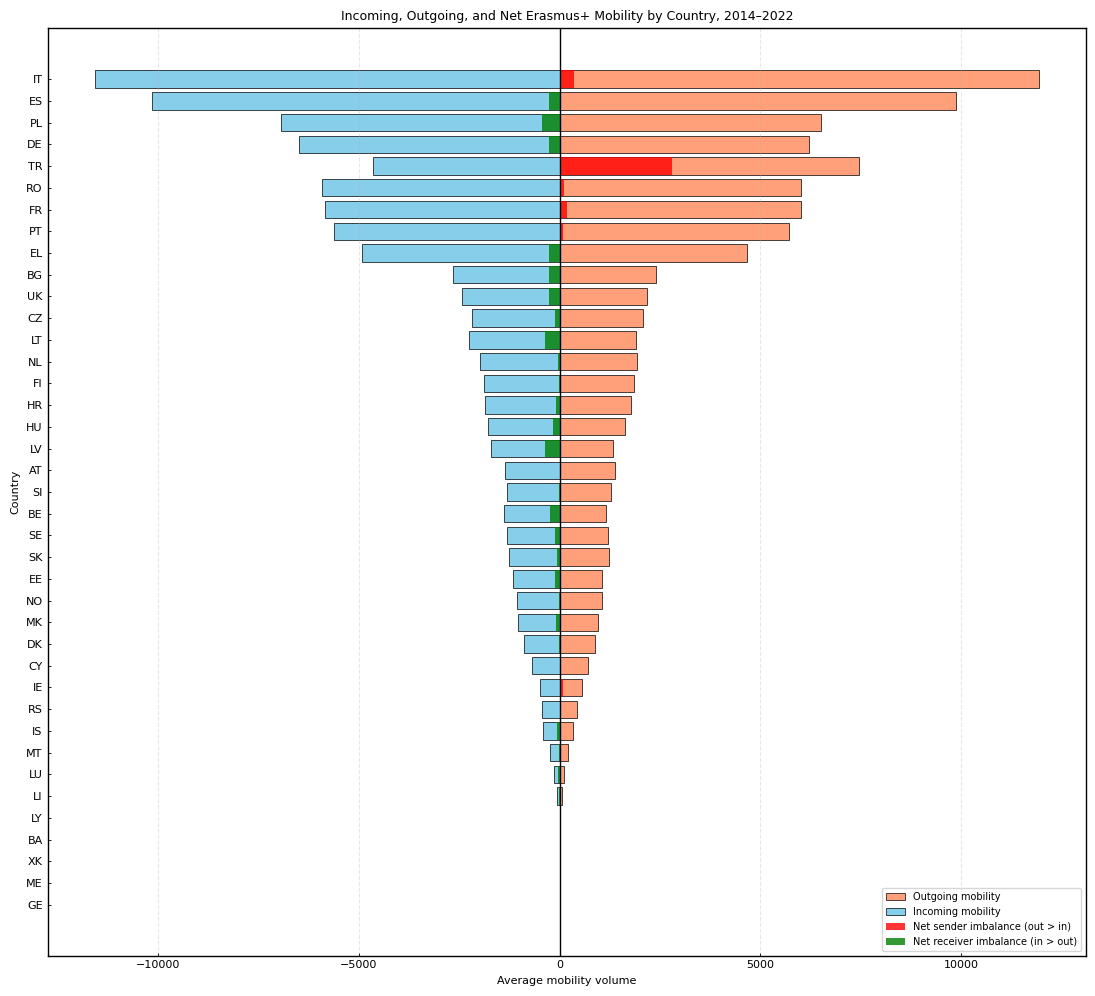

In [10]:
country_role_plot_df = plot_country_roles_diverging(country_avg, top_n=39)

## UK / Brexit

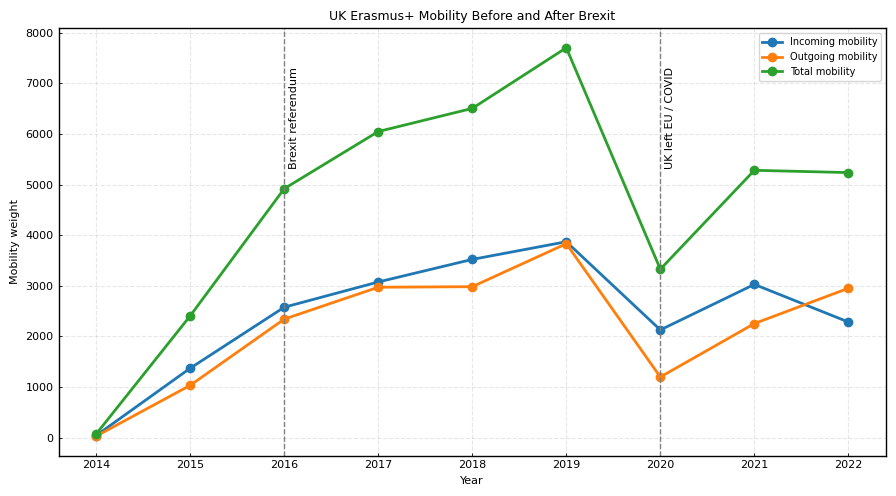

In [11]:
uk_df = plot_uk_brexit(edges_df)

## Bridge countries

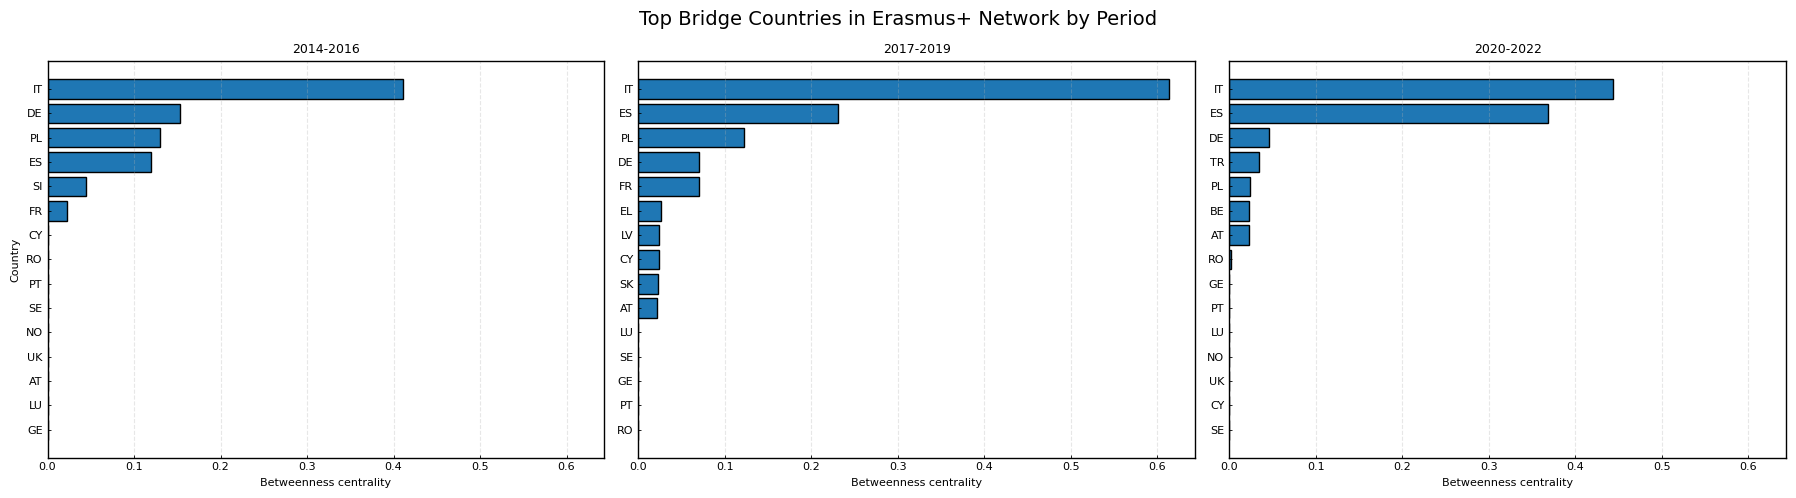

In [12]:
plot_betweenness_by_period(centrality_df, top_n=15)

## Growth contributors

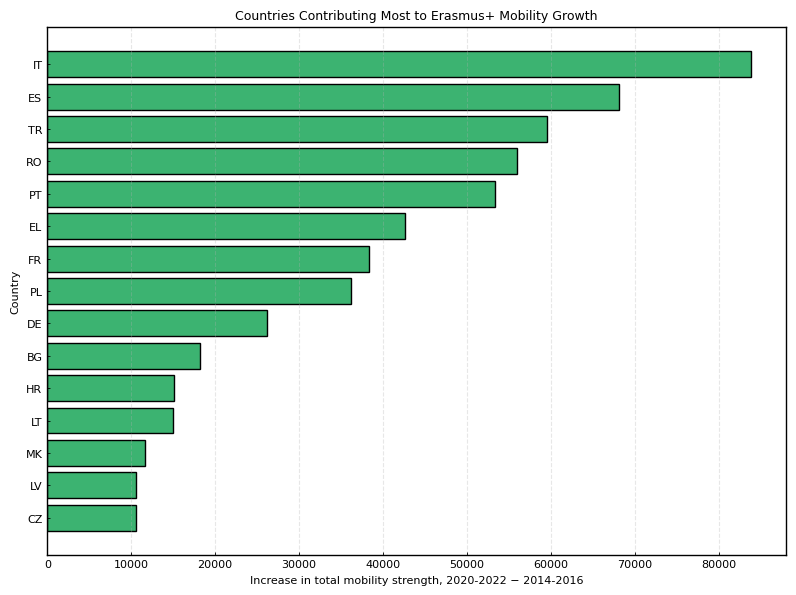

In [13]:
growth_df = plot_growth_contributors(centrality_df, start_period='2014-2016', end_period='2020-2022', top_n=15)

## Activity group shares

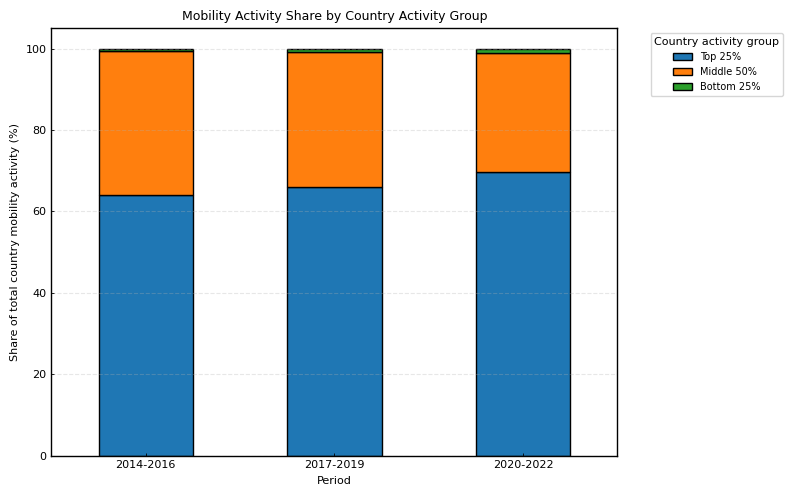

In [14]:
activity_group_df = plot_activity_group_share(centrality_df)